In [ ]:
from google.colab import files
uploaded = files.upload()

Saving PPICellAdhesion_InterCellType_JaccardSimilarity.dat to PPICellAdhesion_InterCellType_JaccardSimilarity.dat


In [ ]:
import pandas as pd

# Read the CSV file with error handling and flexible delimiter
try:
    dfX = pd.read_csv(
        'PPICellAdhesion_InterCellType_JaccardSimilarity.dat',
        # Removed delimiter=' '
        index_col=False,
        # Handle errors by skipping bad lines or raising warnings
        # on_bad_lines='skip',  # Skip lines with too many fields
        # on_bad_lines='warn',  # Print a warning for bad lines
        # Flexible delimiter to handle extra spaces
        delim_whitespace=True,
    )
except pd.errors.ParserError as e:
    print(f"Error reading file: {e}")
    # Inspect line 227 manually for inconsistencies
    with open('PPICellAdhesion_InterCellType_JaccardSimilarity.dat', 'r') as f:
        for i, line in enumerate(f):
            if i == 226:  # Line numbers are 0-based
                print(f"Line 227: {line.strip()}")
                break

# Print some info if successful
if dfX is not None:
    print(dfX.head())
    print(dfX.info())


   I  J  Similarity
0  1  2    0.260000
1  1  3    0.291498
2  1  4    0.295302
3  1  5    0.170068
4  1  6    0.441624
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 820 entries, 0 to 819
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   I           820 non-null    int64  
 1   J           820 non-null    int64  
 2   Similarity  820 non-null    float64
dtypes: float64(1), int64(2)
memory usage: 19.3 KB
None


<ipython-input-3-0381dd0734e7>:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dfX = pd.read_csv(


In [ ]:
# Access columns using their index or actual names
column_1 = dfX['I']  # Changed df to dfX
column_2 = dfX['J']  # Changed df to dfX
column_3 = dfX['Similarity']  # Changed df to dfX

# Print the specific columns
print(column_1)
print(column_2)
print(column_3)

0       1
1       1
2       1
3       1
4       1
       ..
815    38
816    38
817    39
818    39
819    40
Name: I, Length: 820, dtype: int64
0       2
1       3
2       4
3       5
4       6
       ..
815    40
816    41
817    40
818    41
819    41
Name: J, Length: 820, dtype: int64
0      0.260000
1      0.291498
2      0.295302
3      0.170068
4      0.441624
         ...   
815    0.058065
816    0.053435
817    0.125000
818    0.225989
819    0.208122
Name: Similarity, Length: 820, dtype: float64


In [ ]:

    for i in range(0, 41):
        for j in range(i, 42):
            for k in range(0, 820):
                if column_1[k] == i and column_2[k] == j:
                    similarity = column_3[k]
                    print(i , j , similarity)


1 2 0.2599999904632568
1 3 0.2914979755878448
1 4 0.295302003622055
1 5 0.1700680255889892
1 6 0.4416243731975555
1 7 0.3706293702125549
1 8 0.2828282713890075
1 9 0.3706293702125549
1 10 0.4071856141090393
1 11 1.0
1 12 0.1822916716337204
1 13 0.3187499940395355
1 14 0.2692307829856872
1 15 0.205263152718544
1 16 0.4416243731975555
1 17 0.205263152718544
1 18 0.25
1 19 0.2678571343421936
1 20 0.25
1 21 0.2914979755878448
1 22 0.3187499940395355
1 23 0.2107843160629272
1 24 0.5
1 25 0.4318181872367858
1 26 0.4071856141090393
1 27 0.325966864824295
1 28 0.1085271313786506
1 29 0.2512315213680267
1 30 0.2752808928489685
1 31 0.1859504133462905
1 32 0.2107843160629272
1 33 0.2156862765550613
1 34 0.0964467003941536
1 35 0.2319999933242797
1 36 0.1533333361148834
1 37 0.2484472095966339
1 38 0.07246376574039459
1 39 0.1822916716337204
1 40 0.2653061151504516
1 41 0.2402234673500061
2 3 0.4066390097141265
2 4 0.170329675078392
2 5 0.1497005969285965
2 6 0.2408163249492645
2 7 0.213483139872

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np


def modularity_weighted(G, communities):
    """
    Calculate the modularity of the network for a given community structure, considering edge weights.
    """
    # Change: Access the 'weight' attribute from the edge data dictionary
    m = sum([d.get('weight', 1) for u, v, d in G.edges(data=True)])  # Total weight of edges in the graph
    Q = 0
    alpha = 0.5
    for community in communities:
        # Get the subgraph for the community
        subgraph = G.subgraph(community)
        # Change: Access the 'weight' attribute from the edge data dictionary
        lc = sum([d.get('weight', 1) for u, v, d in subgraph.edges(data=True)])  # Total weight of edges within the community
        # Change: Access the 'weight' attribute from the edge data dictionary
        dc = sum([G[u][v].get('weight', 1) for u in community for v in community if G.has_edge(u, v)])  # Degree sum for the community
        Q += alpha * lc / (2 * m) - (1 - alpha) * (dc / (2 * m)) ** 2
    return Q

def CNM_algorithm_weighted(G):
    """
    Perform the Clauset-Newman-Moore community detection algorithm on a weighted graph.
    """
    # Step 1: Initialize each node as its own community
    communities = [{n} for n in G.nodes()]

    def community_merge(c1, c2):
        """ Merge two communities c1 and c2 """
        return c1 | c2

    def best_merge(communities):
        """ Find the best pair of communities to merge by maximizing modularity """
        best_Q = -np.inf
        best_pair = None
        best_communities = communities.copy()

        for i in range(len(communities)):
            for j in range(i + 1, len(communities)):
                # Merge communities i and j
                merged = community_merge(communities[i], communities[j])
                temp_communities = communities[:i] + communities[i+1:j] + communities[j+1:] + [merged]
                current_Q = modularity_weighted(G, temp_communities)

                if current_Q > best_Q:
                    best_Q = current_Q
                    best_pair = (i, j)
                    best_communities = temp_communities
        return best_pair, best_communities, best_Q

    # Step 3: Repeatedly merge communities
    while True:
        pair, new_communities, best_modularity = best_merge(communities)

        # If no improvement in modularity, stop
        if best_modularity <= modularity_weighted(G, communities):
            break

        # Merge the best pair of communities
        communities = new_communities

    return communities


if __name__ == "__main__":

    # Create a graph object
    G = nx.Graph()

    for i in range(0, 41):
        for j in range(i, 42):
            for k in range(0, 820):
                if column_1[k] == i and column_2[k] == j:
                    similarity = column_3[k]
                   # print(i , j , similarity)
                    if similarity > 0.25:
                         G.add_edge(i, j, weight=similarity)
      # Perform community detection using CNM
    communities = CNM_algorithm_weighted(G)

    # Print the communities
    print("Detected communities:")
    for community in communities:
        print("level 1:", community)
        for i in community:
            print(i , column_1[i])

Detected communities:
level 1: {1, 3, 6, 8, 10, 11, 16, 21, 24, 26}
1 1
3 1
6 1
8 1
10 1
11 1
16 1
21 1
24 1
26 1
level 1: {2, 7, 40, 9, 13, 14, 18, 19, 20, 22, 25, 27, 28, 30}
2 1
7 1
40 2
9 1
13 1
14 1
18 1
19 1
20 1
22 1
25 1
27 1
28 1
30 1
level 1: {4, 5, 12, 15, 17, 23, 29, 31, 32, 33, 34, 36, 37, 38, 39, 41}
4 1
5 1
12 1
15 1
17 1
23 1
29 1
31 1
32 1
33 1
34 1
36 1
37 1
38 1
39 1
41 2


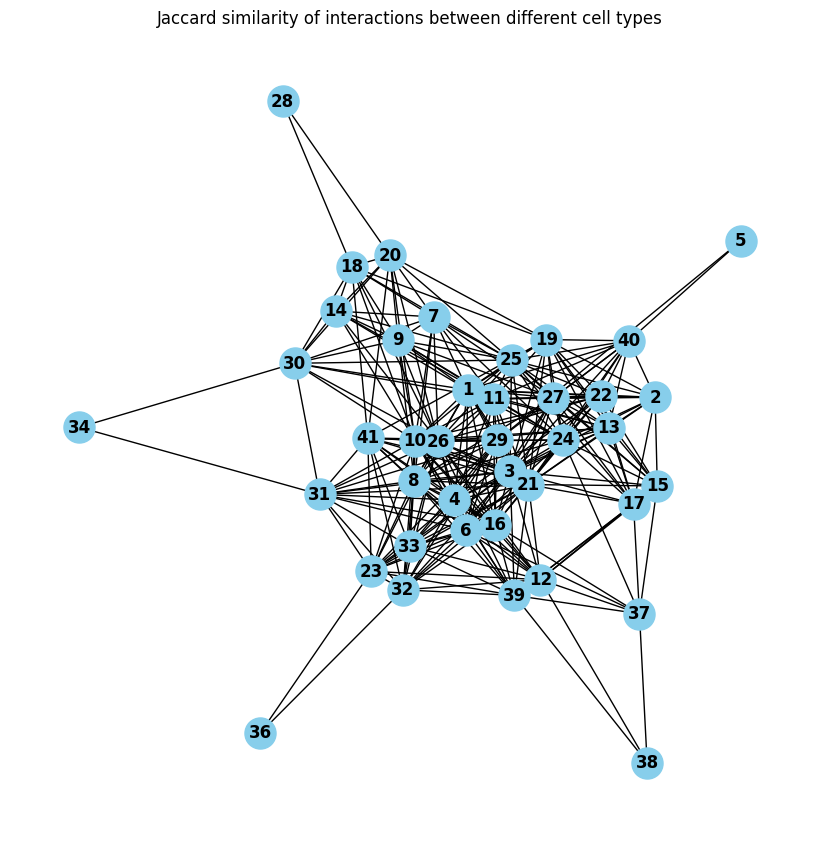

In [ ]:
if __name__ == "__main__":

    # Create a graph object
    G = nx.Graph()

    for i in range(0, 41):
        for j in range(i, 42):
            for k in range(0, 820):
                if column_1[k] == i and column_2[k] == j:
                    similarity = column_3[k]
                   # print(i , j , similarity)
                    if similarity > 0.25:
                         G.add_edge(i, j, weight=similarity)

    # Draw the graph with customized visualization
    plt.figure(figsize=(8, 8))
    nx.draw(G, with_labels=True, node_size=500, node_color='skyblue', font_size=12, font_weight='bold', edge_color='black')
    plt.title("Jaccard similarity of interactions between different cell types")
    plt.show()

